In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import bundle_adjust
import glob
import json
import rpcm
import sys

print("ok")

ok


### Bundle adjustment with lightglue matching

Input data successfully set!

Running bundle adjustment for RPC model refinement ...
Path to log file: /mnt/cdisk/roger/lightglue_ba_outputs/JAX_068_toy/ba_files/JAX_068_toy/bundle_adjust.log


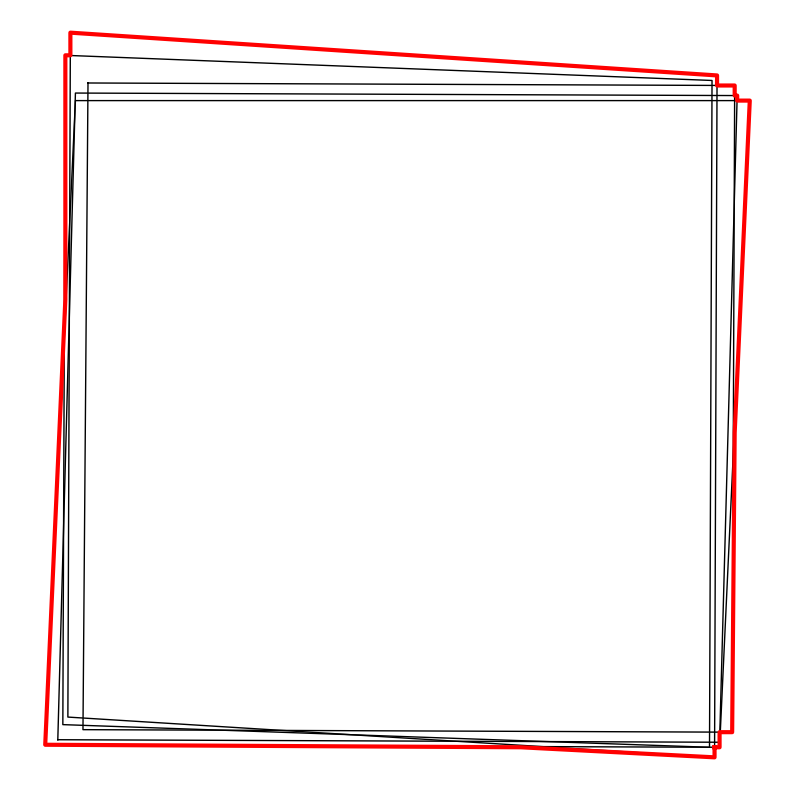

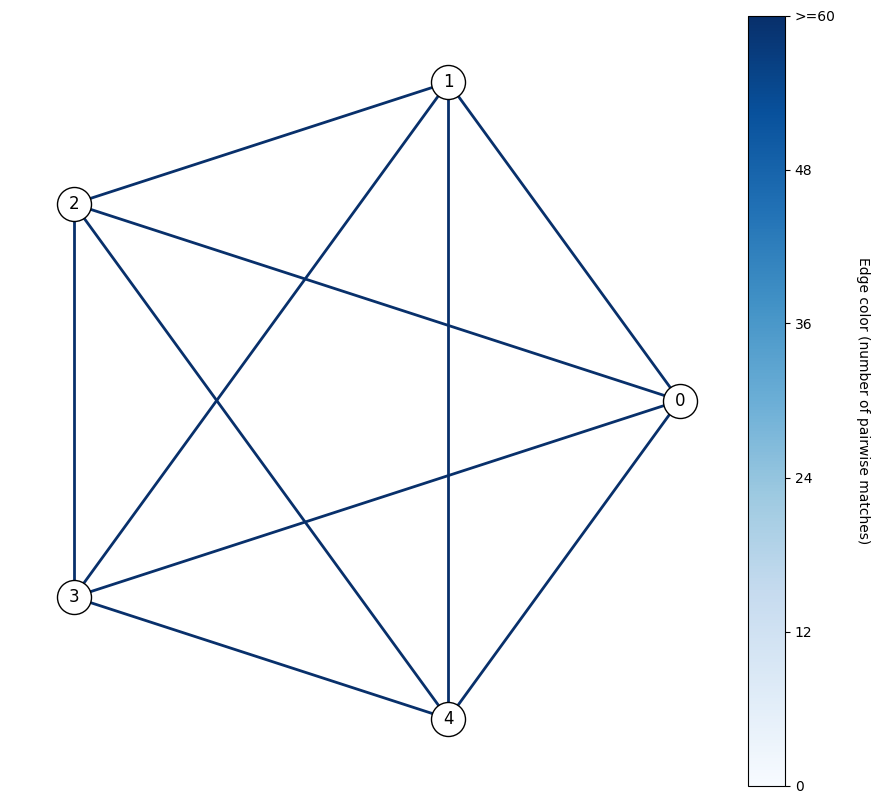

... done !
Path to bundle adjustment files: /mnt/cdisk/roger/lightglue_ba_outputs/JAX_068_toy/ba_files/JAX_068_toy
All done! Path to bundle-adjusted root_dir: /mnt/cdisk/roger/lightglue_ba_outputs/JAX_068_toy/root_dir_ba/JAX_068_toy


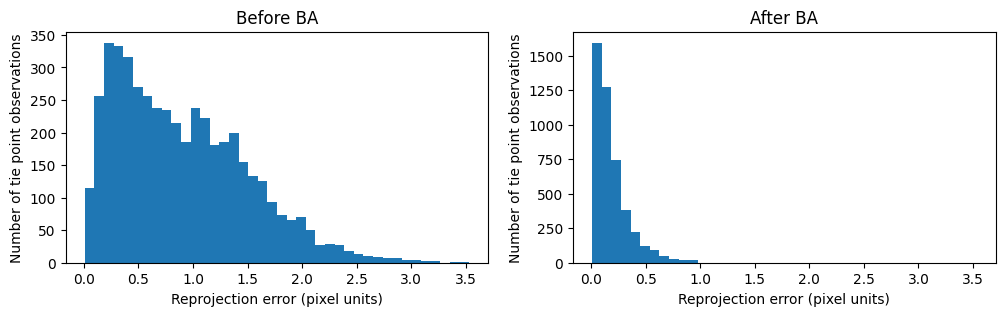

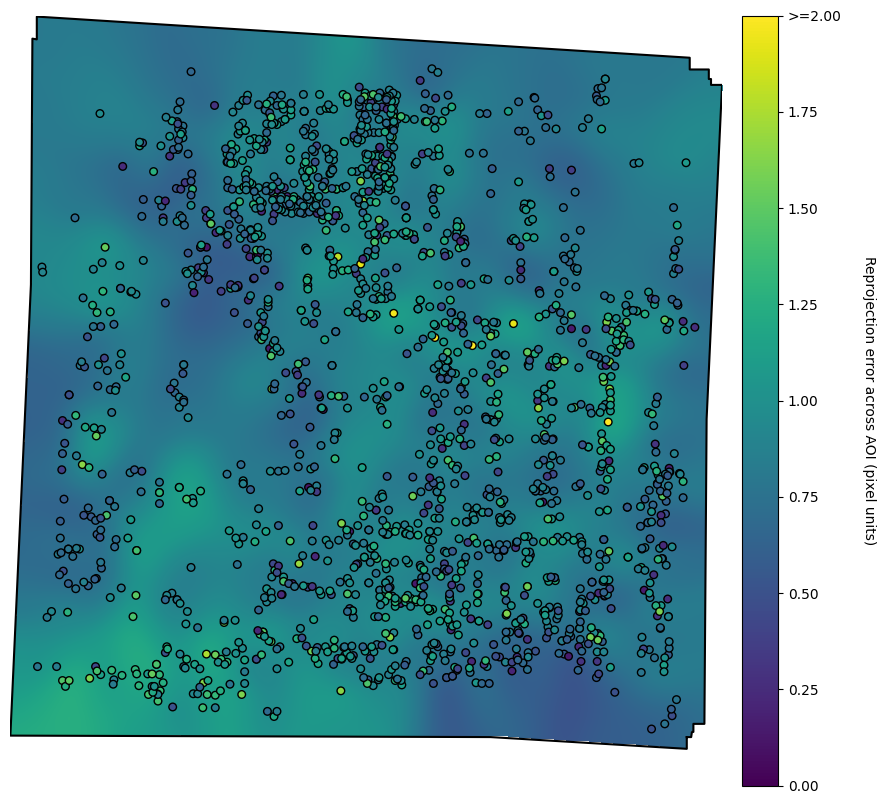

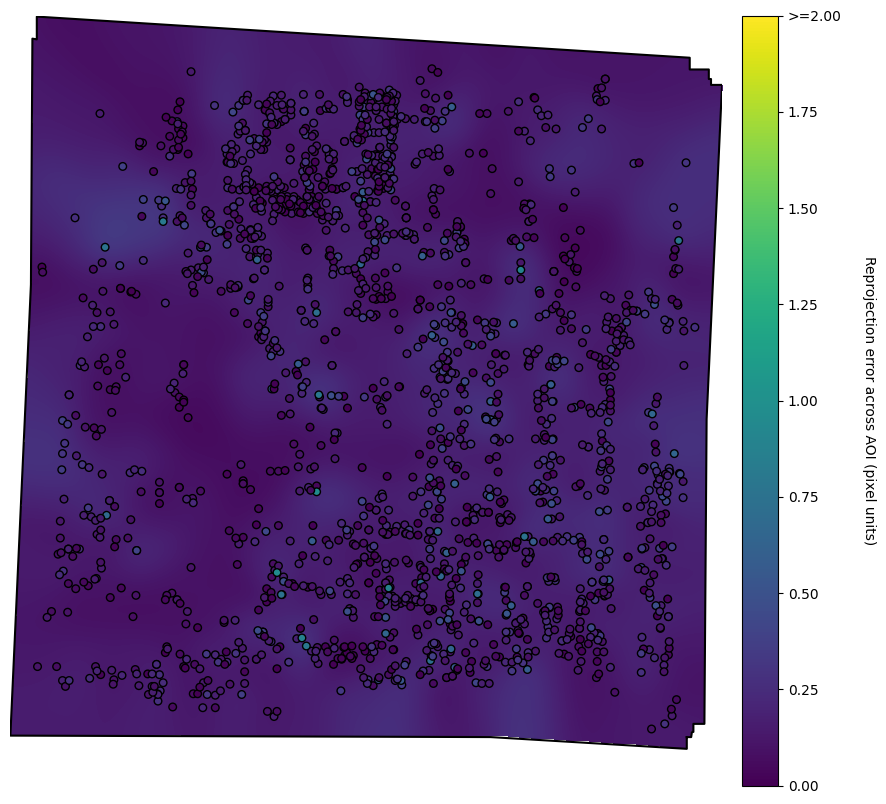

In [4]:
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

IMAGES_TO_IGNORE = {
    "JAX": ["6", "8", "9"],
    "UCSD": ["30", "31", "7"],
    "OMA": ["12"]
}

def rpc_from_json(json_path, return_dict=False):
    with open(json_path) as f:
        d = json.load(f)
    if return_dict:
        return d["rpc"]
    return rpcm.RPCModel(d["rpc"], dict_format="rpcm")

def run_ba(dataset_path, aoi_id, output_dir=None, save_tmp_files=False, overwrite=False, max_keypoints=None, dem_file=None):

    from bundle_adjust.cam_utils import SatelliteImage
    from bundle_adjust.ba_pipeline import BundleAdjustmentPipeline
    from bundle_adjust import loader

    run_ba = True

    img_dir = os.path.join(dataset_path, "input_crops", aoi_id)
    in_rpc_dir = os.path.join(dataset_path, "root_dir", aoi_id)
    if output_dir is None:
        out_rpc_dir = os.path.join(dataset_path, "root_dir_ba", aoi_id)
        ba_files_dir = os.path.join(dataset_path, "ba_files", aoi_id)
    else:
        out_rpc_dir = os.path.join(output_dir, "root_dir_ba", aoi_id)
        ba_files_dir = os.path.join(output_dir, "ba_files", aoi_id)


    # overwrite if needed
    if os.path.exists(out_rpc_dir) and not overwrite:
        print("Output_dir already exists! Skipping!\n")
        return None
    else:
        os.makedirs(out_rpc_dir, exist_ok=True)

    # load input data
    myimages = sorted(glob.glob(img_dir + "/*.tif"))
    # Ignore badly localized images
    myimages = [im for im in myimages if os.path.basename(im).split("_")[-2].split(".")[0] not in IMAGES_TO_IGNORE.get(aoi_id.split("_")[0], [])]
    myjsons = [os.path.join(in_rpc_dir, os.path.basename(p).replace(".tif", ".json")) for p in myimages]
    for p1, p2 in zip(myjsons, myimages):
        assert os.path.exists(p1) and os.path.exists(p2)
    #myrpcs = [rpcm.rpc_from_geotiff(p) for p in mypanimages]
    myrpcs = [rpc_from_json(p) for p in myjsons]
    input_images = [SatelliteImage(fn, rpc) for fn, rpc in zip(myimages, myrpcs)]
    ba_input_data = {}
    ba_input_data['in_dir'] = img_dir
    ba_input_data['out_dir'] = ba_files_dir
    ba_input_data['images'] = input_images

    print('Input data successfully set!\n')

    # redirect all prints to a bundle adjustment logfile inside the output directory
    os.makedirs(ba_input_data['out_dir'], exist_ok=True)
    path_to_log_file = "{}/bundle_adjust.log".format(ba_input_data['out_dir'])
    print("Running bundle adjustment for RPC model refinement ...")
    print(f"Path to log file: {path_to_log_file}")
    log_file = open(path_to_log_file, "w+")
    sys.stdout = log_file
    sys.stderr = log_file
    # run bundle adjustment
    #tracks_config = {'FT_reset': True, 'FT_sift_detection': 's2p', 'FT_sift_matching': 'epipolar_based', "FT_K": 300}
    # tracks_config = {'FT_reset': False, 'FT_save': True, 'FT_sift_detection': 's2p', 'FT_sift_matching': 'epipolar_based', "FT_kp_max": 20000, "FT_n_proc": 12}
    if max_keypoints is None:
        tracks_config = {'FT_reset': False, 'FT_save': True, 'FT_sift_detection': 's2p', 'FT_sift_matching': 'epipolar_based', "FT_n_proc": 12}
    else:
        tracks_config = {'FT_reset': False, 'FT_save': True, 'FT_sift_detection': 's2p', 'FT_sift_matching': 'epipolar_based', "FT_kp_max": max_keypoints, "FT_n_proc": 12}
    ba_extra = {"cam_model": "rpc", "dem_file": dem_file}
    tracks_config['FT_sift_matching'] = 'lightglue'
    ba_pipeline = BundleAdjustmentPipeline(ba_input_data, tracks_config=tracks_config, extra_ba_config=ba_extra)
    ba_pipeline.run()
    # close logfile
    sys.stderr = sys.__stderr__
    sys.stdout = sys.__stdout__
    log_file.close()
    print("... done !")
    print(f"Path to bundle adjustment files: {ba_input_data['out_dir']}")


    # save all bundle adjustment parameters in a temporary directory if needed for debugging
    if save_tmp_files:
        ba_params_dir = os.path.join(ba_pipeline.out_dir, "ba_params")
        os.makedirs(ba_params_dir, exist_ok=True)
        np.save(os.path.join(ba_params_dir, "pts_ind.npy"), ba_pipeline.ba_params.pts_ind)
        np.save(os.path.join(ba_params_dir, "cam_ind.npy"), ba_pipeline.ba_params.cam_ind)
        np.save(os.path.join(ba_params_dir, "pts3d.npy"), ba_pipeline.ba_params.pts3d_ba - ba_pipeline.global_transform)
        np.save(os.path.join(ba_params_dir, "pts2d.npy"), ba_pipeline.ba_params.pts2d)
        fnames_in_use = [ba_pipeline.images[idx].geotiff_path for idx in ba_pipeline.ba_params.cam_prev_indices]
        loader.save_list_of_paths(os.path.join(ba_params_dir, "geotiff_paths.txt"), fnames_in_use)

    for in_json_path in myjsons:
        with open(in_json_path) as f:
            d = json.load(f)
        rpc_adj_path = os.path.join(ba_files_dir, f"rpcs_adj/{os.path.basename(in_json_path).replace('.json', '.rpc_adj')}")
        if not os.path.exists(rpc_adj_path):
            continue
        d["rpc"] = rpcm.rpc_from_rpc_file(rpc_adj_path).__dict__
        out_json_path = os.path.join(out_rpc_dir, os.path.basename(in_json_path))
        os.makedirs(out_rpc_dir, exist_ok=True)
        with open(out_json_path, "w") as f:
            json.dump(d, f, indent=2)
    print(f"All done! Path to bundle-adjusted root_dir: {out_rpc_dir}")


dataset_path = "/mnt/cdisk/roger/lightglue_ba_outputs"
aoi_id = "JAX_068_toy"
output_dir = f"/mnt/cdisk/roger/lightglue_ba_outputs/{aoi_id}"
max_kps = 10000

run_ba(dataset_path, aoi_id, output_dir=output_dir, save_tmp_files=False, overwrite=True, max_keypoints=max_kps, dem_file=None)

### Toy example: rotate SIFT keypoints

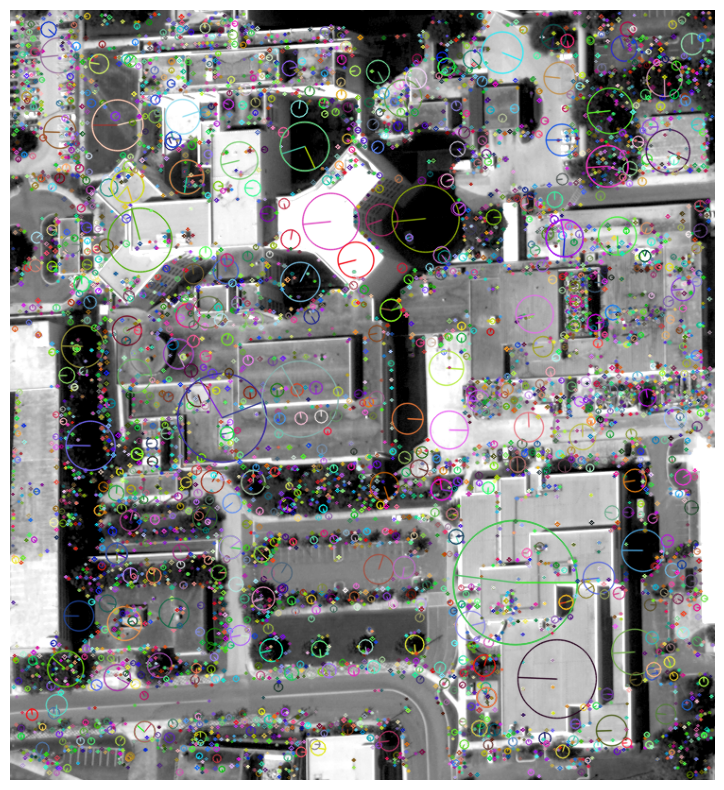

In [161]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import rasterio
from bundle_adjust import loader

# load image (grayscale for SIFT)
img_path = "/mnt/cdisk/roger/lightglue_ba_outputs/input_crops/JAX_068_toy/JAX_068_001_RGB.tif"
img = loader.load_image(img_path, offset=None, equalize=True)
im = img.astype(np.uint8)
# create SIFT detector
sift = cv2.SIFT_create()

# detect keypoints and compute descriptors
keypoints, descriptors = sift.detectAndCompute(im, None)

# draw keypoints on the image
img_kp = cv2.drawKeypoints(
    im, keypoints, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# convert BGR (OpenCV default) to RGB for matplotlib
img_kp = cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB)

# display with matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(img_kp)
plt.axis("off")
plt.show()

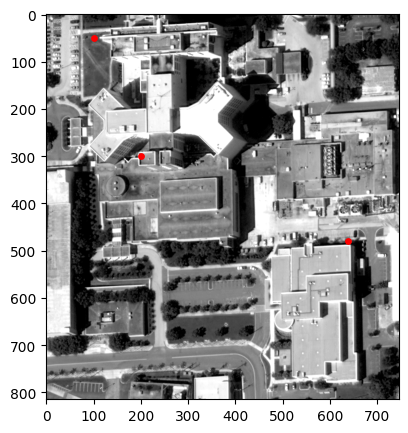

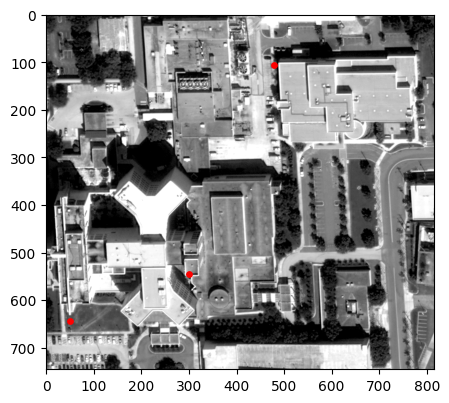

In [162]:
import numpy as np

def affine_image_rotation(w, h, phi_deg, center=None):
    phi = np.deg2rad(phi_deg)
    c, s = np.cos(phi), np.sin(phi)
    # counterclockwise rotation matrix
    R = np.array([[c, s],
                  [-s,  c]], dtype=float)

    if center is None:
        center = np.array([(w - 1) / 2.0, (h - 1) / 2.0], dtype=float)  # (cx, cy)

    # Original image corners in (x,y)
    corners = np.array([[0,     0],
                        [w - 1, 0],
                        [0,     h - 1],
                        [w - 1, h - 1]], dtype=float)

    # Rotate corners about the chosen center
    rc = (corners - center) @ R.T + center

    # Compute translation so that all rotated corners are inside the new canvas
    min_xy = rc.min(axis=0)                    # (min_x, min_y)
    t = -min_xy                                # shift so mins are at 0

    # New canvas size (W', H') that tightly fits the rotated image
    max_xy = rc.max(axis=0)
    w_new = int(np.ceil(max_xy[0] - min_xy[0] + 1))
    h_new = int(np.ceil(max_xy[1] - min_xy[1] + 1))

    # Build 2x3 affine: [R | b], with b = -R*c + c + t
    b = (-R @ center) + center + t
    A = np.hstack([R, b.reshape(2, 1)])        # shape (2,3)

    return A, (w_new, h_new)

def rotate_points(points, A):
    pts = np.asarray(points, dtype=float)      # (N,2) as (x,y)
    R = A[:, :2]
    b = A[:, 2]
    return pts @ R.T + b

# --- Example usage ---
# im.shape -> (H, W, ...)
H, W = im.shape
A, (W2, H2) = affine_image_rotation(W, H, phi_deg=90.0)  # any angle
pts = np.array([[100, 50], [200, 300], [639, 479]], float)   # (x,y)
rot_pts = rotate_points(pts, A)

plt.figure(figsize=(5, 5))
plt.imshow(im, cmap="gray")
plt.scatter(pts[:, 0], pts[:, 1], s=15, c="r")
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(im_rot, cmap="gray")
plt.scatter(rot_pts[:, 0], rot_pts[:, 1], s=15, c="r")
plt.show()

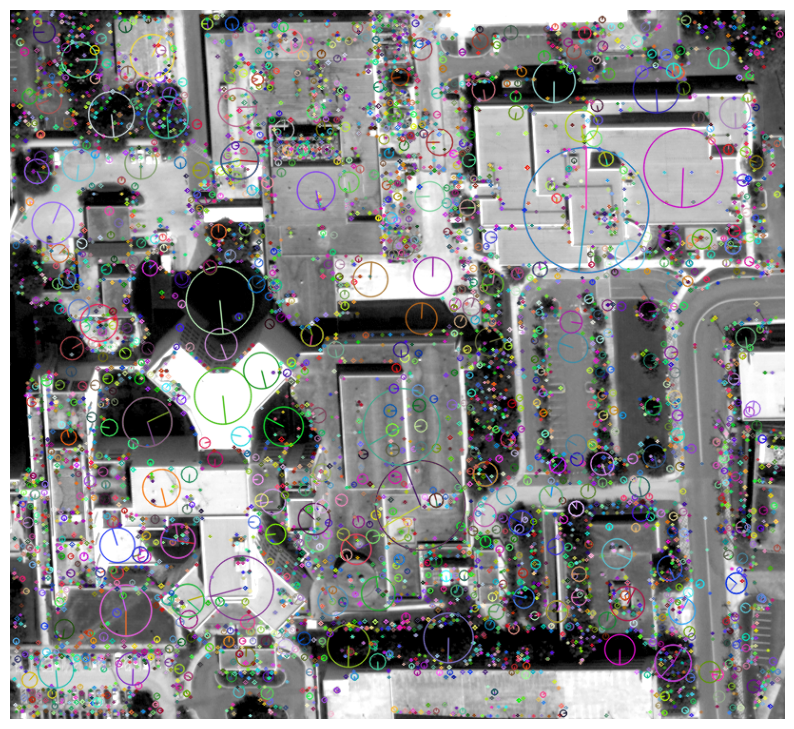

In [163]:
phi_deg = 90
sift_features = np.array([[*k.pt, k.size, k.angle, *d] for k, d in zip(keypoints, descriptors)])
kp_coordinates = np.vstack([sift_features[:, 0], sift_features[:, 1]]).T

H, W = im.shape
A, _ = affine_image_rotation(W, H, phi_deg=90.0)
rot_kp_coordinates = rotate_points(kp_coordinates, A)

keypoints_rot = keypoints + tuple()
for i in range(len(keypoints_rot)):
    keypoints_rot[i].pt = rot_kp_coordinates[i]
    keypoints_rot[i].angle -= phi_deg

im_rot = np.rot90(im, k=1)
img_kp = cv2.drawKeypoints(
    im_rot, keypoints_rot, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# convert BGR (OpenCV default) to RGB for matplotlib
img_kp = cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB)

# display with matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(img_kp)
plt.axis("off")
plt.show()